**Import Libraries**

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style='whitegrid')

**Load Dataset**

In [ ]:
# Load dataset (upload file first in Colab)
df = pd.read_csv('/content/drive/MyDrive/Market Segmentation/Customer Data.csv')

**Data Analysis**

In [ ]:
# Basic info
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


**Data Preprocessing**

In [ ]:
# Keep only numeric columns automatically
data = df.select_dtypes(include=['number'])

# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

**Correlation Matrix**

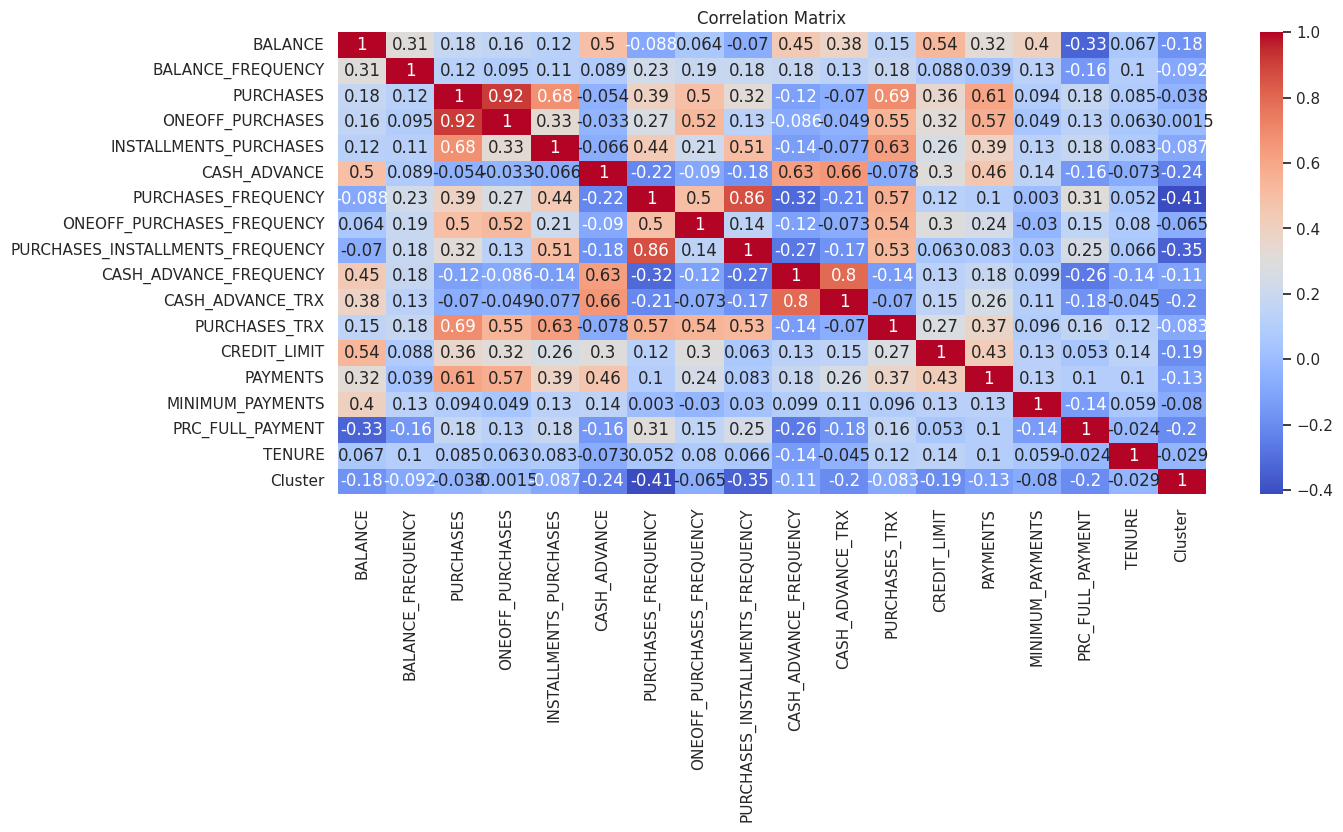

In [ ]:
# Correlation heatmap
plt.figure(figsize=(14,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

**Pairplot**

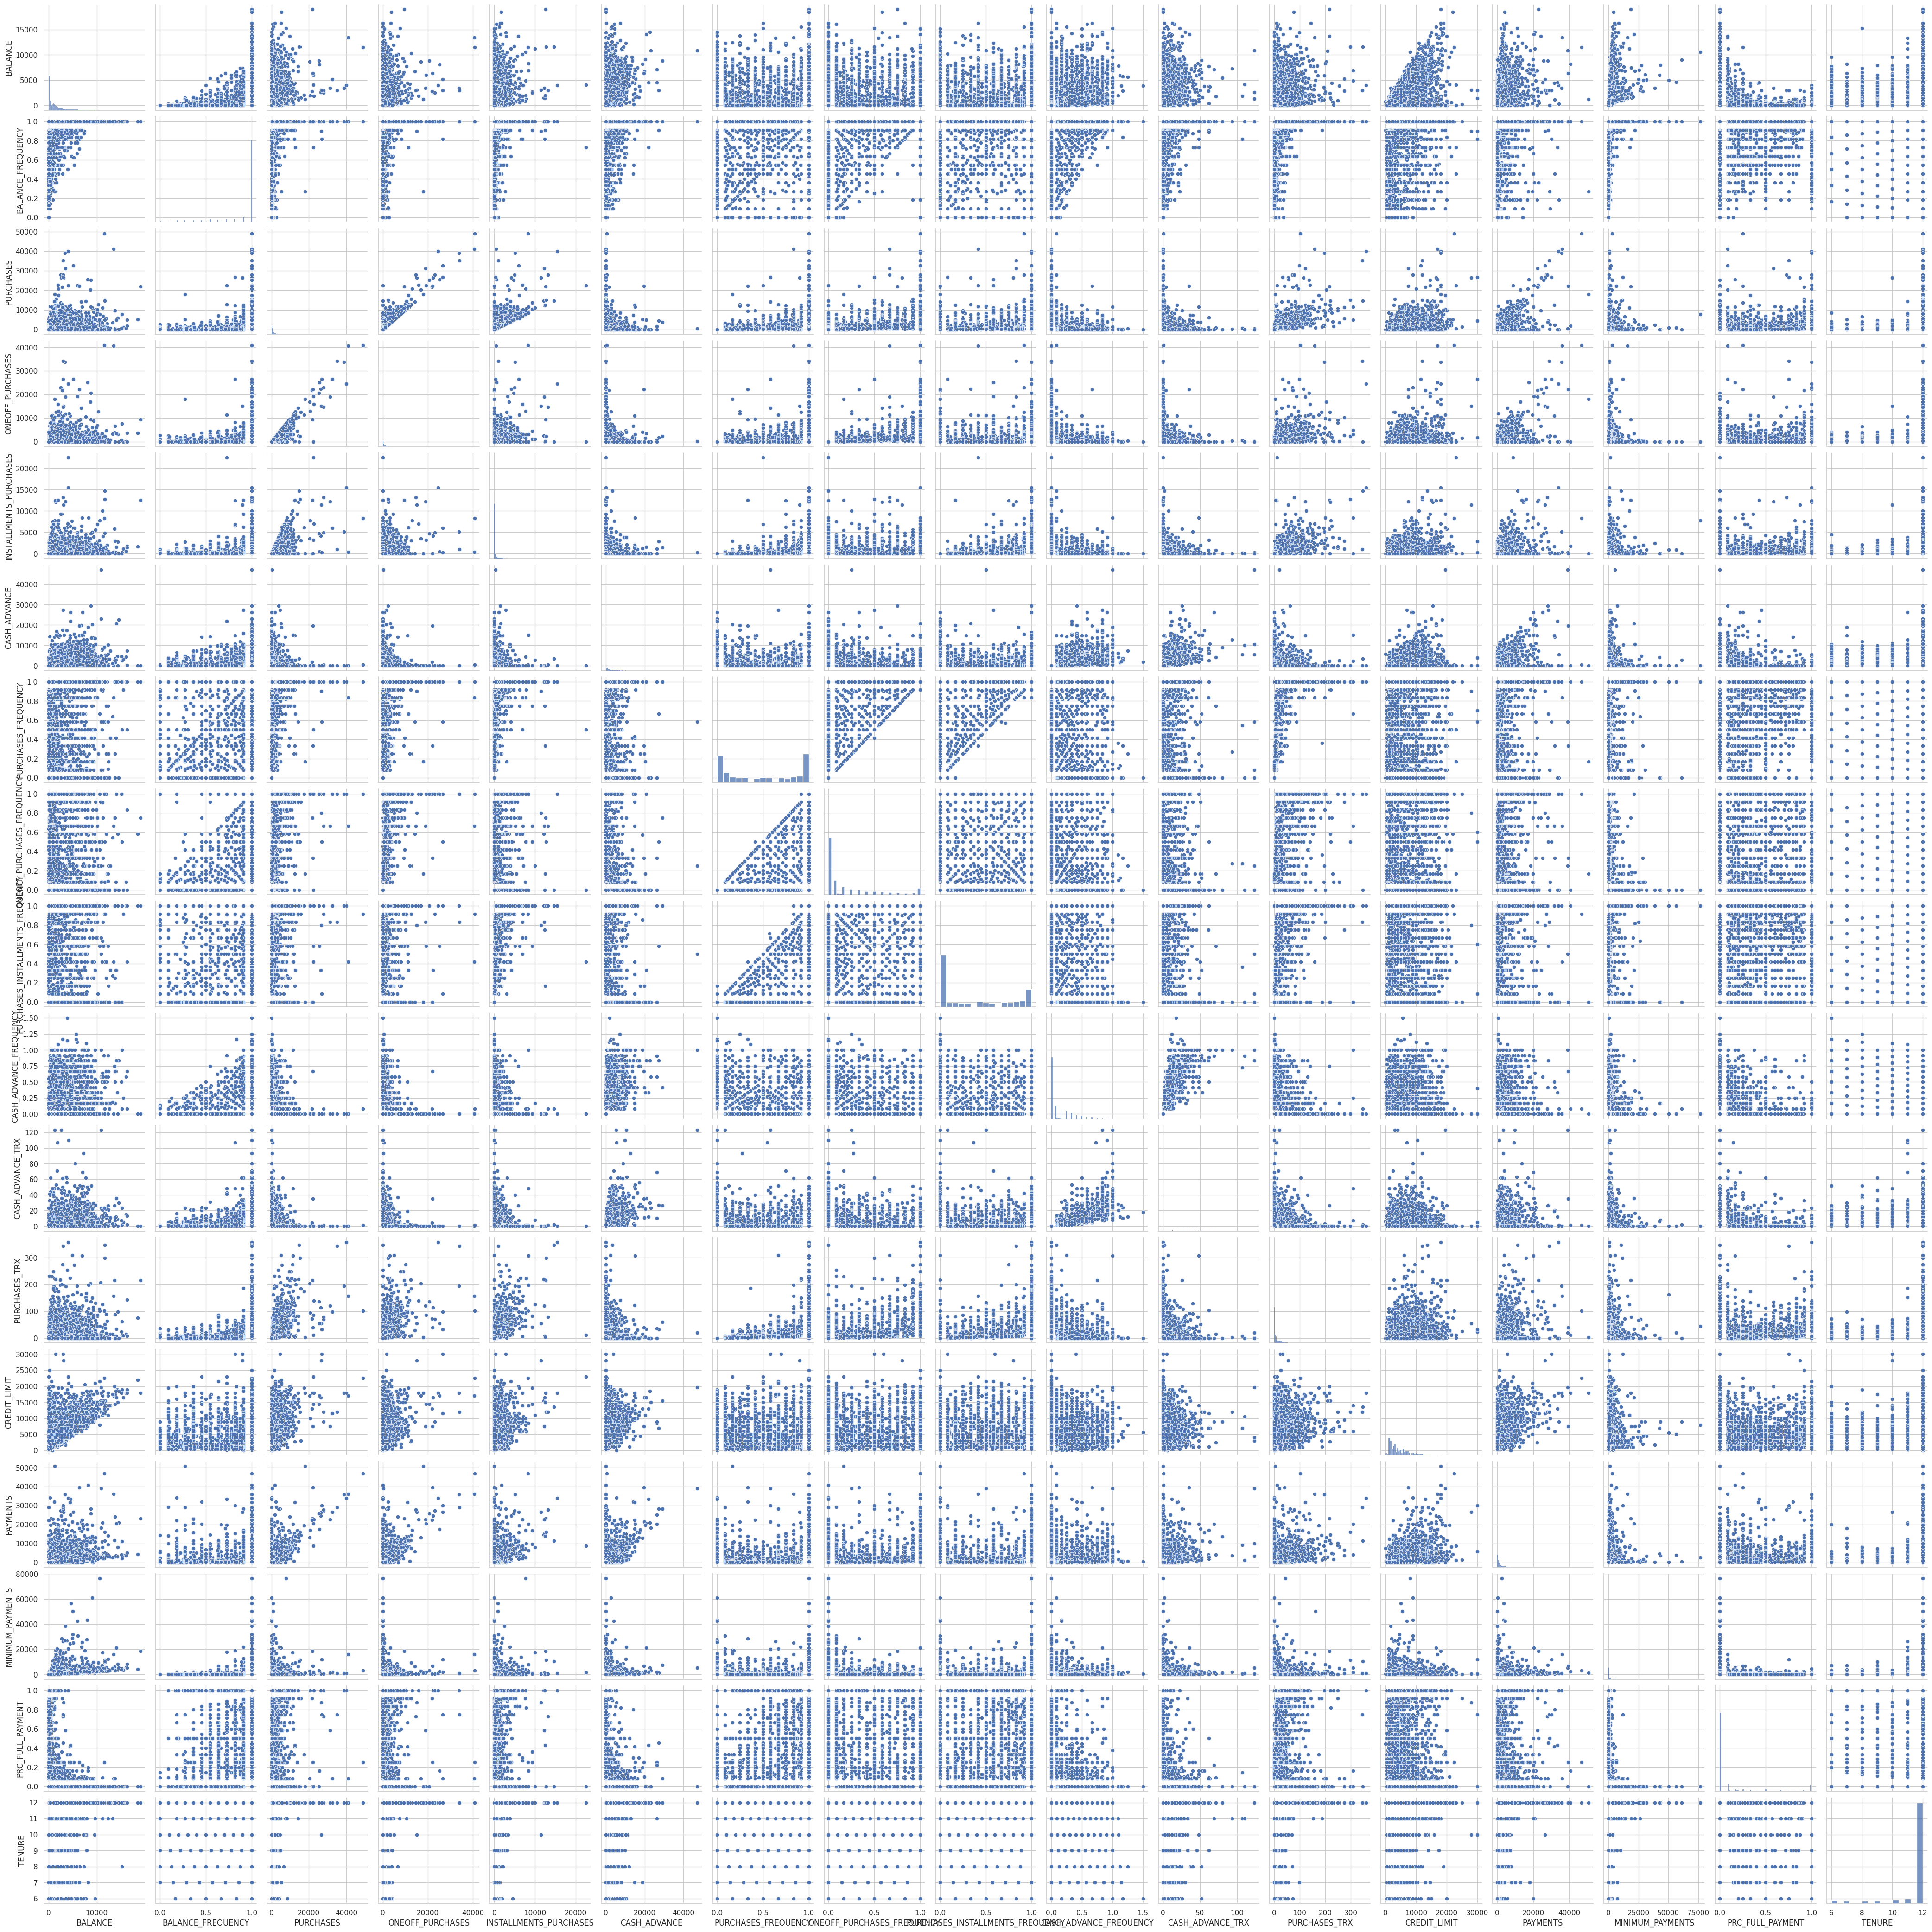

In [ ]:
# Pairplot (feature relationships)
sns.pairplot(data)

plt.show()

**Distribution Plot**

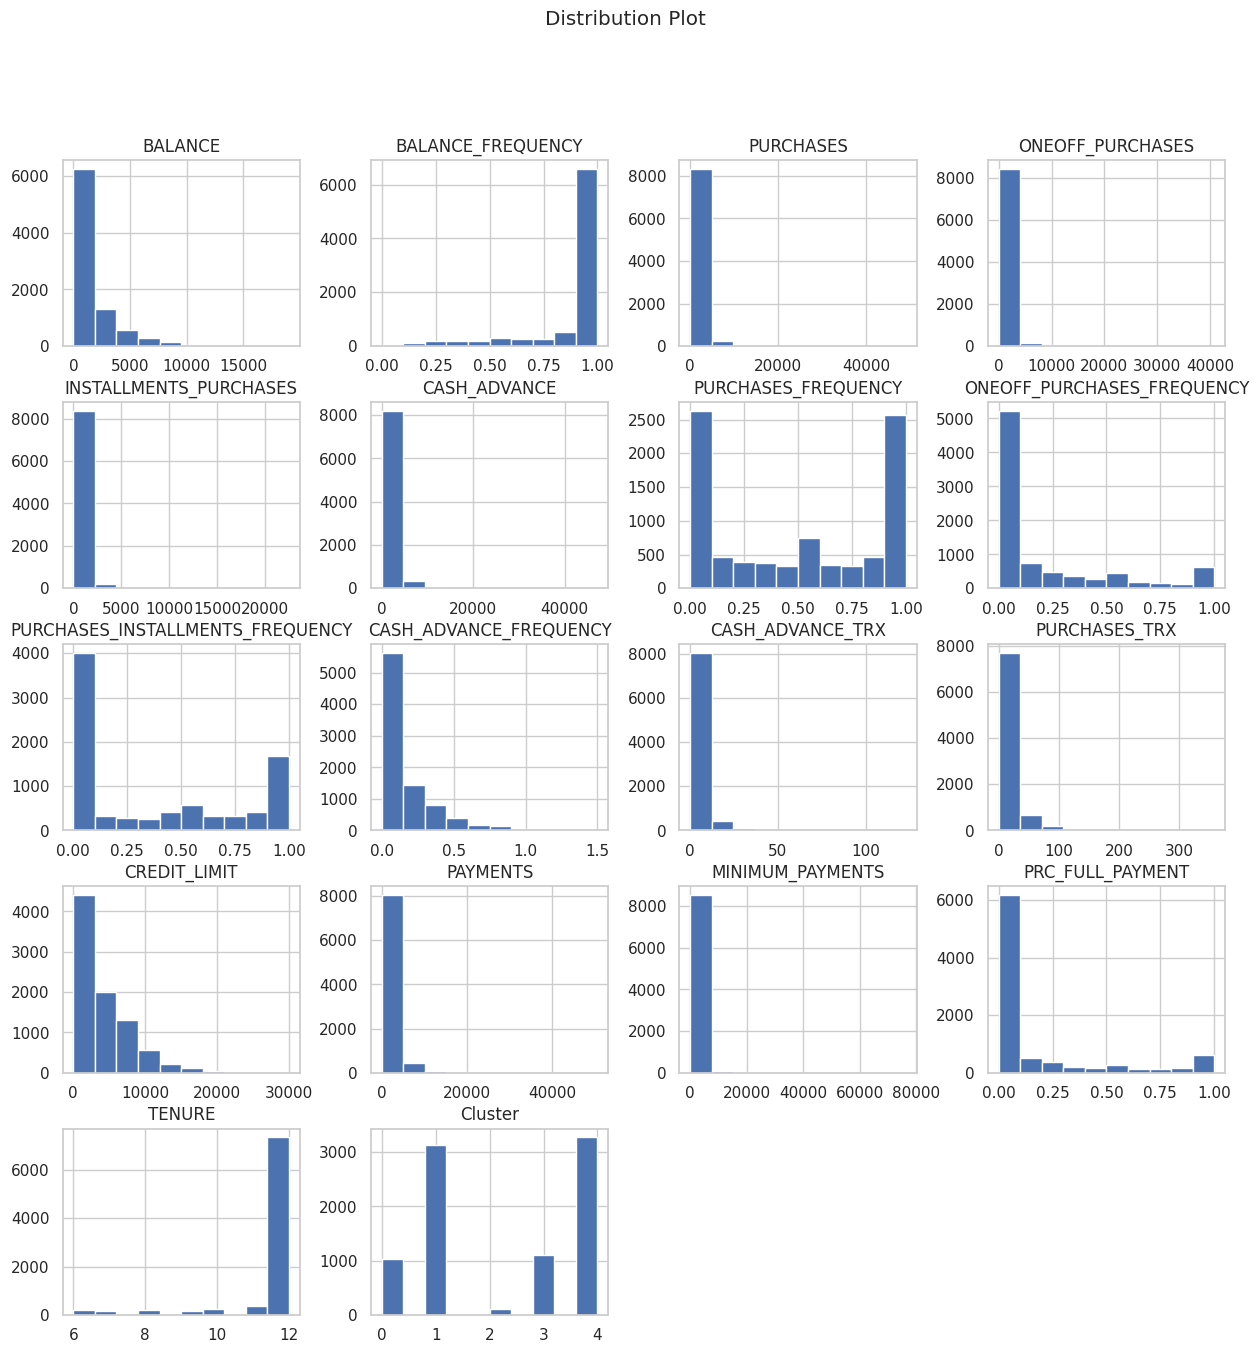

In [ ]:
# Histogram distribution
data.hist(figsize=(15,15))

plt.suptitle("Distribution Plot")
plt.show()

**Box Plot**

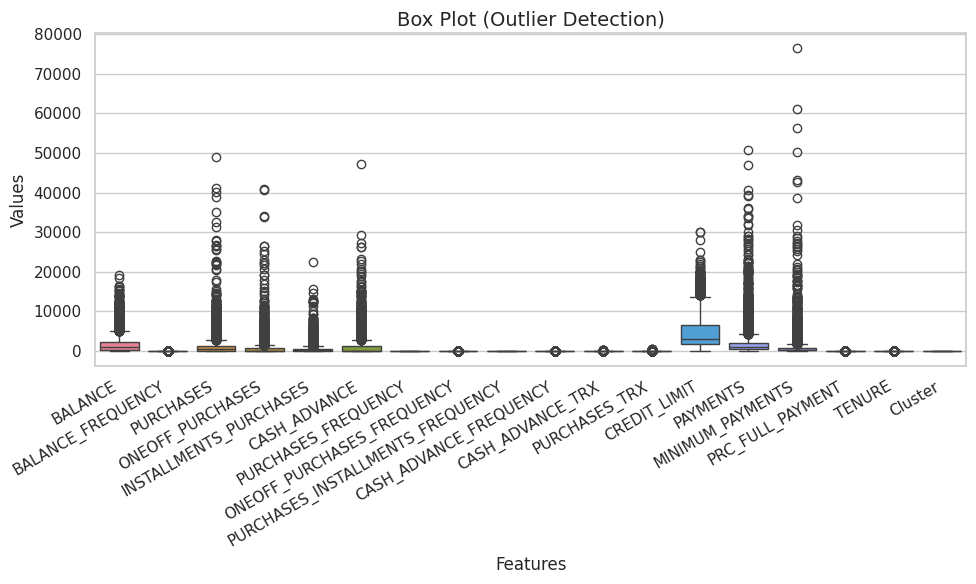

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(data=data)

# Rotate x-axis labels (important)
plt.xticks(rotation=30, ha='right')   # tilt labels

plt.title("Box Plot (Outlier Detection)", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Values")

plt.tight_layout()  # auto spacing fix
plt.show()

**Apply PCA**

In [ ]:
# Remove rows with missing values
data = data.dropna()

# Scale again after cleaning
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

In [ ]:
# Reduce dimensions to 2
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

# Create DataFrame
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

pca_df.head()

,PC1,PC2
0,-1.862495,-1.184021
1,-0.969003,2.606476
2,1.012690,-0.347124
3,-1.775138,-0.794614
4,0.306727,-0.704201


**Plot PCA**

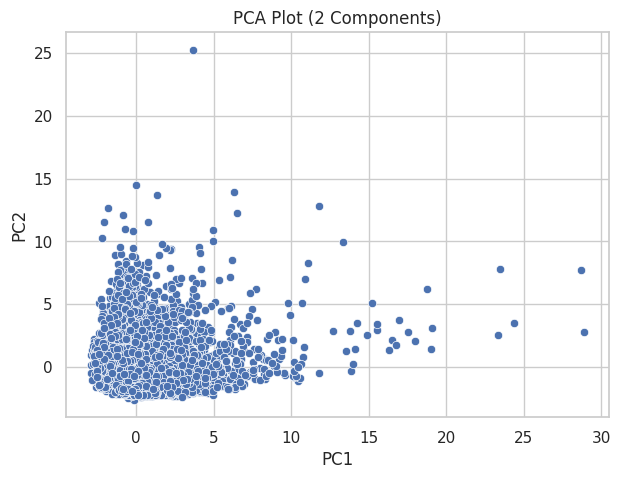

In [ ]:
# Plot PCA
plt.figure(figsize=(7,5))

sns.scatterplot(x='PC1', y='PC2', data=pca_df)

plt.title("PCA Plot (2 Components)")
plt.show()

**Elbow Method**

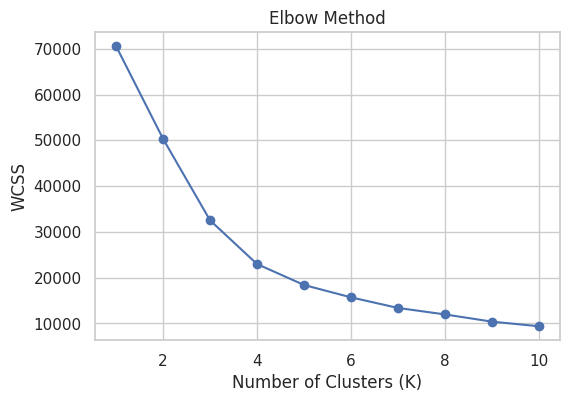

In [ ]:
# Elbow method ( best k )
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

# Plot elbow graph
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

**Apply K-Means**

In [ ]:
# Apply KMeans (choose K=5 based on elbow)
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(pca_data)

# Add cluster column to PCA data
pca_df['Cluster'] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-1.862495,-1.184021,1
1,-0.969003,2.606476,0
2,1.012690,-0.347124,4
3,-1.775138,-0.794614,1
4,0.306727,-0.704201,4


**Plot Clusters**

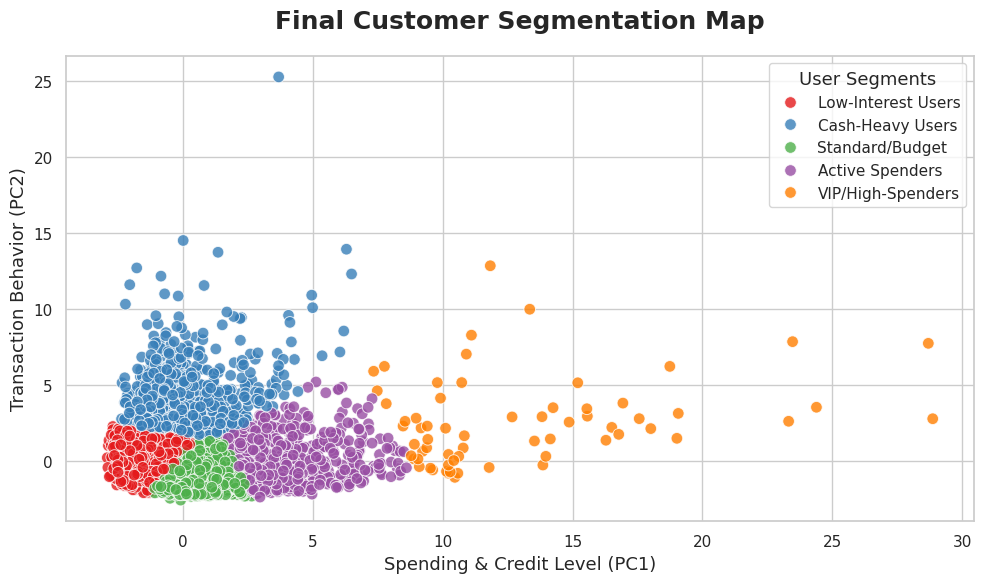

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

segment_map = {
    0: "Cash-Heavy Users",    # Purple: High PC2
    1: "Low-Interest Users",  # Blue: Bottom center
    2: "VIP/High-Spenders",   # Teal: Far right
    3: "Active Spenders",     # Green: Right-middle
    4: "Standard/Budget"      # Yellow: Bottom left
}

pca_df['User_Tag'] = pca_df['Cluster'].map(segment_map)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # Clean background

scatter = sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='User_Tag',
    data=pca_df,
    palette='Set1',   # High-contrast colors
    s=70,             # Larger dots
    alpha=0.8,        # Good transparency
    edgecolor='white' # Contrast between dots
)

plt.title('Final Customer Segmentation Map', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Spending & Credit Level (PC1)', fontsize=13)
plt.ylabel('Transaction Behavior (PC2)', fontsize=13)

plt.legend(title='User Segments', title_fontsize='13', fontsize='11', loc='best', frameon=True)

plt.tight_layout()
plt.show()

**Add Cluster to Original Data**

In [ ]:
# Add cluster to cleaned data
data['Cluster'] = clusters

# Show result
df.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
